# Benchmark Orientation Analysis

In [1]:
import os
print(os.getcwd())

c:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\Notebooks\Use_case_CNT_orientation_analysis\Use_case_CNT_orientation_analysis\notebooks


In [5]:

import os
import pandas as pd

# --- Base paths ---
base_result = r"C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features/output"

polygon_orientation_gt = 'polygon_analysis_groundtruth'
polygon_orientation_pred = 'polygon_analysis_prediction'
fft_orientation = 'fft_analysis_prediction'
fft_orientation_gt_masks = 'fft_analysis_groundtruth'

# --- Build full CSV paths ---
csv_gt = os.path.join(base_result, polygon_orientation_gt, "polygon_orientations.csv")
csv_pred = os.path.join(base_result, polygon_orientation_pred, "polygon_orientations.csv")
csv_fft = os.path.join(base_result, fft_orientation, "orientations.csv")
csv_fft_gt_masks = os.path.join(base_result, fft_orientation_gt_masks, "orientations.csv")

# --- Load CSVs ---
df_pred = pd.read_csv(csv_pred)
df_gt = pd.read_csv(csv_gt)
df_fft = pd.read_csv(csv_fft)
df_fft_gt_masks = pd.read_csv(csv_fft_gt_masks)

# --- Quick check ---
print("Loaded DataFrames:")

print(f"  Ground-truth polygon orientations → {df_gt.shape}")
print(f"  Predicted polygon orientations → {df_pred.shape}")
print(f"  FFT orientations → {df_fft.shape}")
print(f"  FFT orientations of GT masks → {df_fft_gt_masks.shape}")

# Optionally preview the first few rows
print("\nSample preview:")
display(df_gt.head(3))
display(df_pred.head(3))
display(df_fft.head(3))
display(df_fft_gt_masks.head(3))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\abd93000\\Downloads\\downloads\\paper figures\\FFT based features/output\\polygon_analysis_prediction\\polygon_orientations.csv'


=== Orientation Comparison Summary ===


,Method,Mean Abs Error (deg),Median Abs Error (deg),Circular Corr (r),Mean Orientation (deg)
0,Polygon (PCA),7.833333,5.0,0.857749,86.815923
1,FFT,25.666667,12.5,0.162607,118.964549



Paired t-test: is Polygon error < FFT error?
  t = 3.905, p = 0.0005
✅ Polygon orientation (df_pred) is significantly more accurate than FFT.


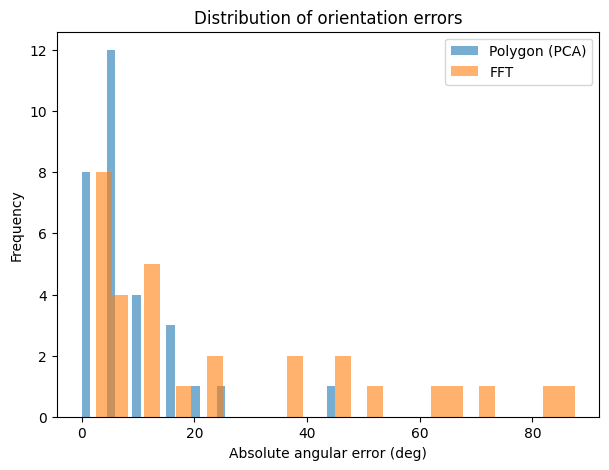

In [2]:
import numpy as np
from scipy.stats import ttest_rel

# --- Helper functions for circular / axial data ---
def to_radians(deg):
    return np.deg2rad(deg)

def axial_diff(a_deg, b_deg):
    """
    Compute minimal angular difference (degrees) between two arrays of axial (0–180°) orientations.
    """
    d = a_deg - b_deg
    # Map to [-180, 180)
    d = (d + 180) % 360 - 180
    # Because axial, map to [-90, 90)
    d = (d + 90) % 180 - 90
    return d

def mean_abs_axial_error(pred_deg, gt_deg):
    return np.mean(np.abs(axial_diff(pred_deg, gt_deg)))

def circular_mean_deg(angles_deg):
    """Compute axial-aware circular mean (degrees)."""
    doubled = np.deg2rad(2 * angles_deg)
    C = np.mean(np.cos(doubled))
    S = np.mean(np.sin(doubled))
    mean_angle = 0.5 * np.rad2deg(np.arctan2(S, C)) % 180
    return mean_angle

def circular_correlation_deg(a_deg, b_deg):
    """
    Compute Jammalamadaka & SenGupta (1988) circular–circular correlation coefficient
    for axial data (angles in degrees, 0–180).
    """
    a = np.deg2rad(2 * a_deg)  # double for axial
    b = np.deg2rad(2 * b_deg)
    a_bar = np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))
    b_bar = np.arctan2(np.mean(np.sin(b)), np.mean(np.cos(b)))
    num = np.sum(np.sin(a - a_bar) * np.sin(b - b_bar))
    den = np.sqrt(np.sum(np.sin(a - a_bar) ** 2) * np.sum(np.sin(b - b_bar) ** 2))
    return num / den if den != 0 else np.nan

# --- Extract numeric columns (assume 'orientation' or similar column names) ---
col_gt = [c for c in df_gt.columns if 'orient' in c.lower()][0]
col_pred = [c for c in df_pred.columns if 'orient' in c.lower()][0]
col_fft = [c for c in df_fft.columns if 'orient' in c.lower()][0]

angles_gt = df_gt[col_gt].to_numpy()
angles_pred = df_pred[col_pred].to_numpy()
angles_fft = df_fft[col_fft].to_numpy()

# --- Compute per-sample errors ---
err_pred = axial_diff(angles_pred, angles_gt)
err_fft = axial_diff(angles_fft, angles_gt)

# --- Compute absolute errors ---
abs_err_pred = np.abs(err_pred)
abs_err_fft = np.abs(err_fft)

# --- Summary stats ---
summary = {
    "Method": ["Polygon (PCA)", "FFT"],
    "Mean Abs Error (deg)": [np.mean(abs_err_pred), np.mean(abs_err_fft)],
    "Median Abs Error (deg)": [np.median(abs_err_pred), np.median(abs_err_fft)],
    "Circular Corr (r)": [
        circular_correlation_deg(angles_pred, angles_gt),
        circular_correlation_deg(angles_fft, angles_gt),
    ],
    "Mean Orientation (deg)": [
        circular_mean_deg(angles_pred),
        circular_mean_deg(angles_fft),
    ],
}
df_summary = pd.DataFrame(summary)

# --- Paired test for difference in abs errors ---
t_stat, p_val = ttest_rel(abs_err_fft, abs_err_pred)

print("\n=== Orientation Comparison Summary ===")
display(df_summary)

print("\nPaired t-test: is Polygon error < FFT error?")
print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05 and np.mean(abs_err_pred) < np.mean(abs_err_fft):
    print("✅ Polygon orientation (df_pred) is significantly more accurate than FFT.")
else:
    print("⚠️ No statistically significant improvement detected.")

# --- Optional visualization ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(abs_err_pred, bins=30, alpha=0.6, label="Polygon (PCA)")
plt.hist(abs_err_fft, bins=30, alpha=0.6, label="FFT")
plt.xlabel("Absolute angular error (deg)")
plt.ylabel("Frequency")
plt.title("Distribution of orientation errors")
plt.legend()
plt.show()


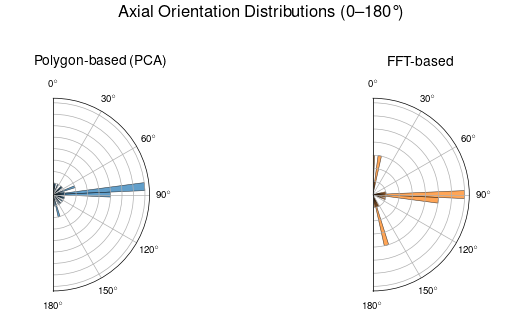

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# --- Activate LaTeX-ready scientific style ---
plt.style.use(['science', 'nature'])  # or add 'no-latex' if you lack TeX Live

# --- Convert degrees → radians (axial domain: 0–π) ---
angles_gt_rad   = np.deg2rad(df_gt[col_gt].to_numpy() % 180)
angles_pred_rad = np.deg2rad(df_pred[col_pred].to_numpy() % 180)
angles_fft_rad  = np.deg2rad(df_fft[col_fft].to_numpy() % 180)

# --- Plot setup ---
bins = 36  # 5° bins over 0–180
width = np.pi / bins

fig, ax = plt.subplots(1, 2, figsize=(6.5, 3), subplot_kw=dict(polar=True))

def rose_plot_axial(ax, angles, color, label):
    """Rose plot for axial (0–π) data, suitable for CNT orientations."""
    counts, bin_edges = np.histogram(angles, bins=bins, range=(0, np.pi))
    bars = ax.bar(bin_edges[:-1], counts, width=width,
                  color=color, alpha=0.7, edgecolor='black', linewidth=0.4)

    # Polar plot configuration
    ax.set_theta_zero_location('N')   # 0° = north (up)
    ax.set_theta_direction(-1)        # clockwise increasing
    ax.set_thetalim(0, np.pi)         # only show 0–180°
    ax.set_thetagrids(np.linspace(0, 180, 7), labels=[
        r"$0^\circ$", r"$30^\circ$", r"$60^\circ$",
        r"$90^\circ$", r"$120^\circ$", r"$150^\circ$", r"$180^\circ$"
    ])
    ax.set_yticklabels([])
    ax.set_title(label, fontsize=10, pad=10)

# --- Plot polygon-based vs FFT-based ---
rose_plot_axial(ax[0], angles_pred_rad, 'tab:blue',  'Polygon-based (PCA)')
rose_plot_axial(ax[1], angles_fft_rad,  'tab:orange','FFT-based')

fig.suptitle("Axial Orientation Distributions (0–180°)", fontsize=12, y=1.05)
fig.tight_layout()

# --- Save high-quality figures for publication ---
# plt.savefig("orientation_rose_ACSnano.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("orientation_rose_ACSnano.png", dpi=300, bbox_inches='tight')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


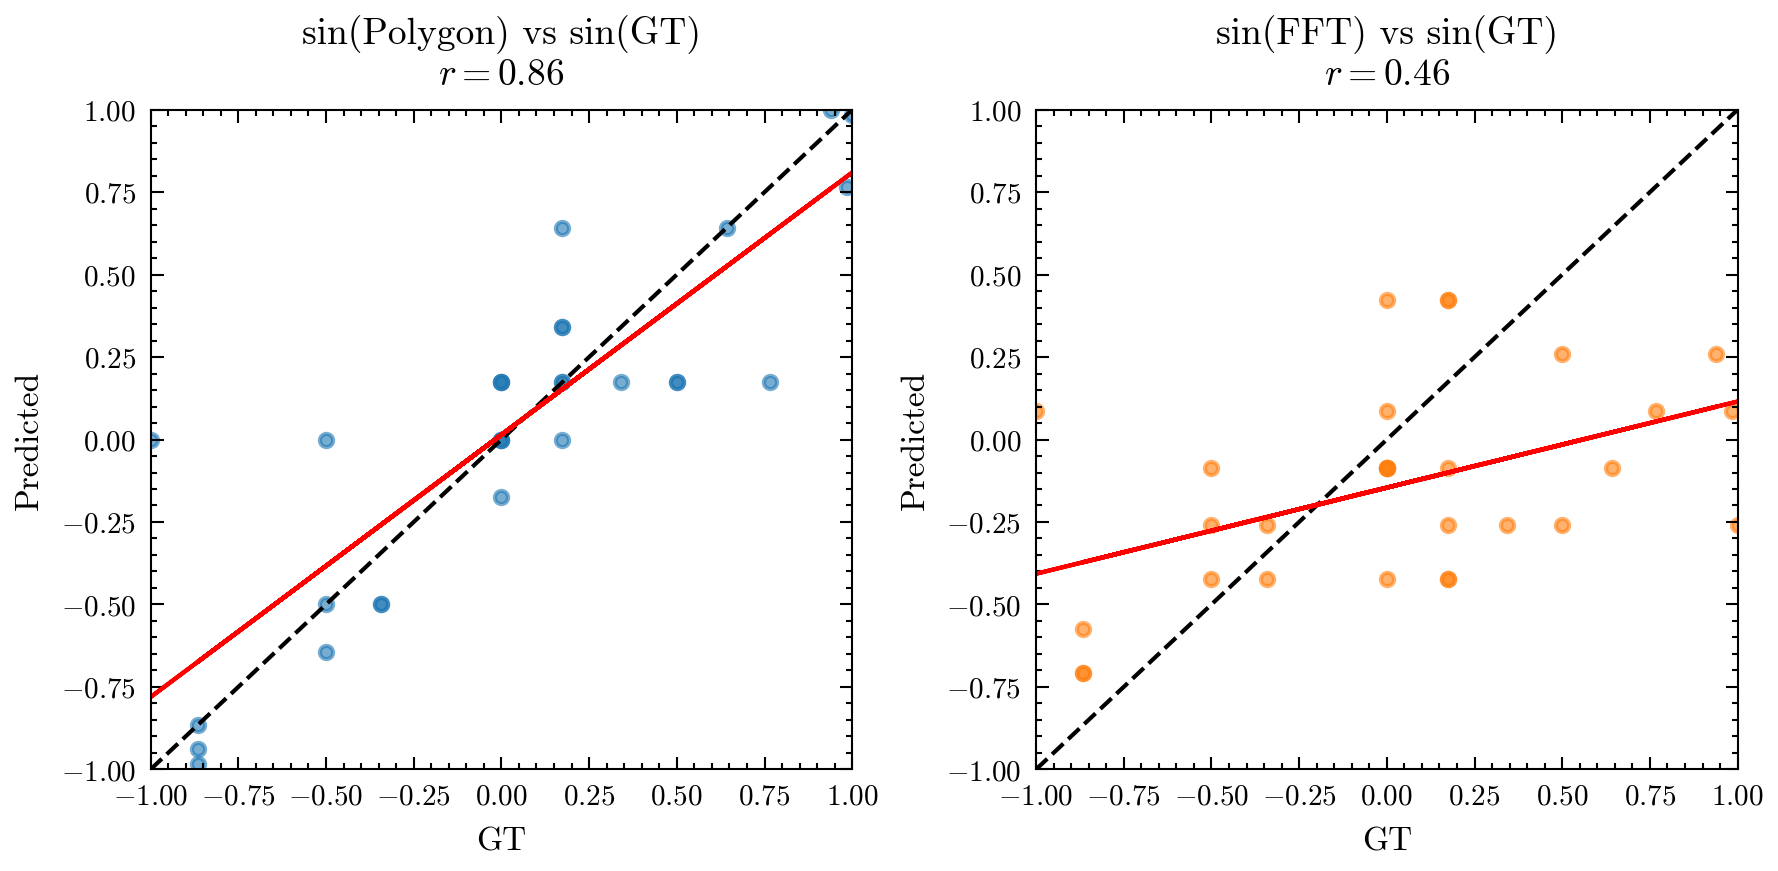

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


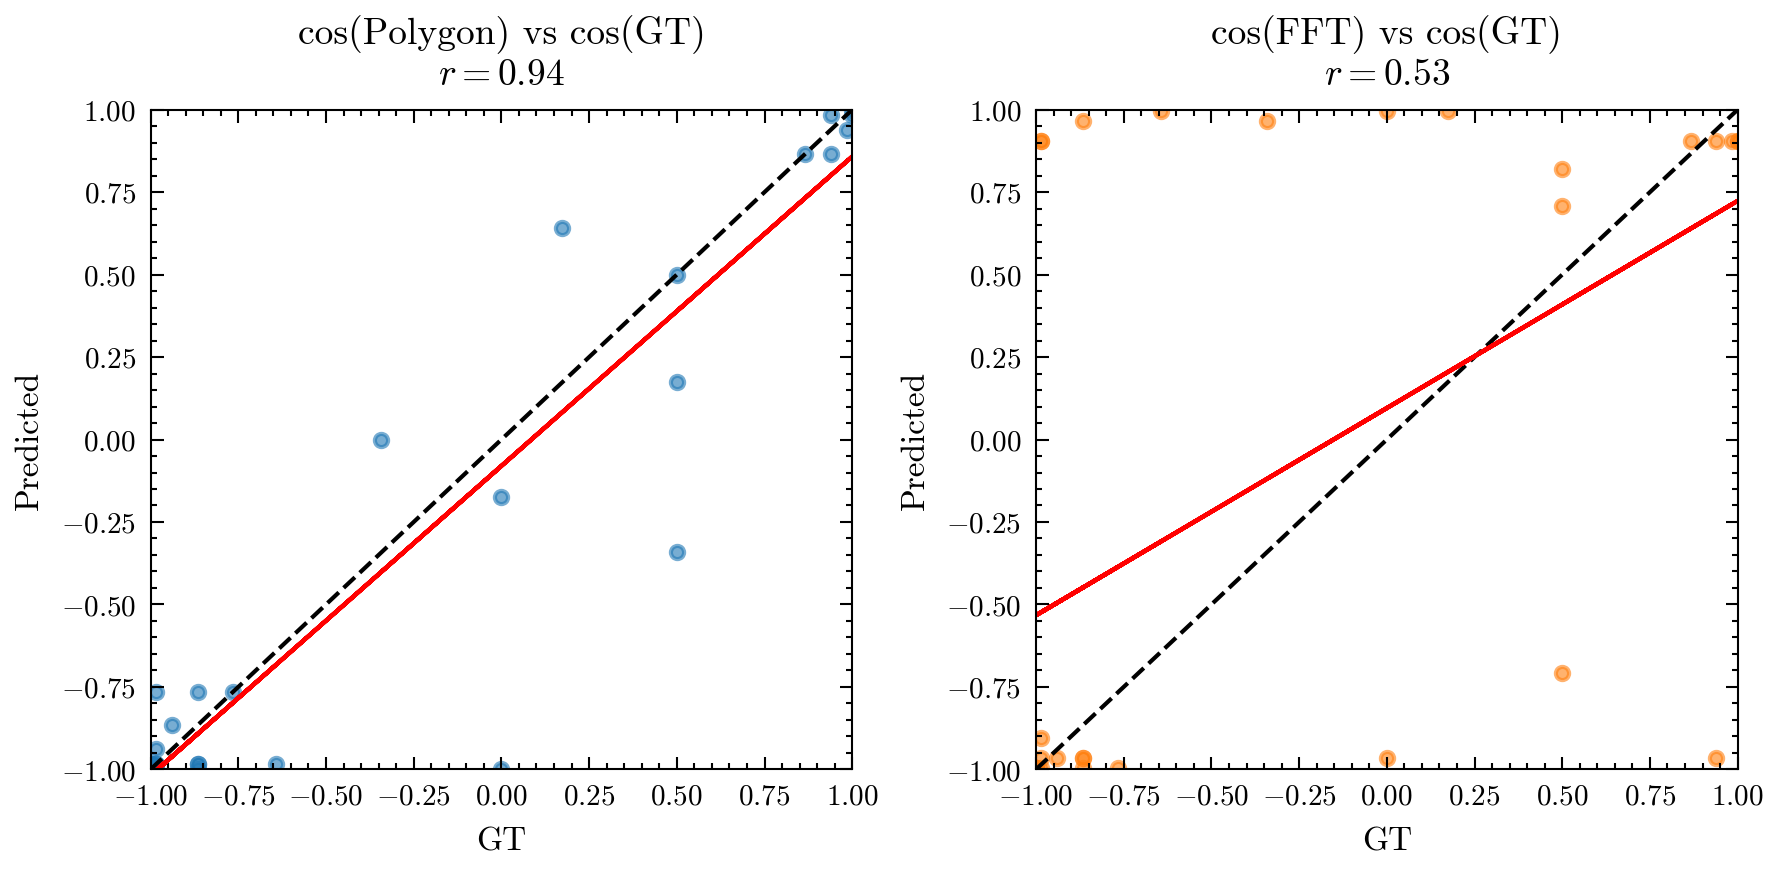

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import linregress

plt.style.use(['science', 'nature', 'no-latex'])

# --- Convert degrees → radians (axial 0–180) ---
angles_gt_rad   = np.deg2rad(df_gt[col_gt].to_numpy() % 180)
angles_pred_rad = np.deg2rad(df_pred[col_pred].to_numpy() % 180)
angles_fft_rad  = np.deg2rad(df_fft[col_fft].to_numpy() % 180)

# --- Compute sin and cos components (axial data) ---
angles_gt_doubled   = 2 * angles_gt_rad
angles_pred_doubled = 2 * angles_pred_rad
angles_fft_doubled  = 2 * angles_fft_rad

gt_cos   = np.cos(angles_gt_doubled)
gt_sin   = np.sin(angles_gt_doubled)
pred_cos = np.cos(angles_pred_doubled)
pred_sin = np.sin(angles_pred_doubled)
fft_cos  = np.cos(angles_fft_doubled)
fft_sin  = np.sin(angles_fft_doubled)

# --- 4-panel figure for ACS Nano single column ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)  # width ~ single column
axes = axes.ravel()
panels = [
    (gt_sin, pred_sin, "sin(Polygon) vs sin(GT)", "tab:blue"),
    (gt_sin, fft_sin,  "sin(FFT) vs sin(GT)",  "tab:orange"),
]

for ax, (x, y, title, color) in zip(axes, panels):
    # Scatter
    ax.scatter(x, y, alpha=0.6, color=color, s=10)  # smaller points
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    ax.plot([-1,1],[-1,1],'k--', lw=1)  # y=x line
    ax.plot(x, intercept + slope*x, 'r-', lw=1)  # regression line
    
    # Axes
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_xlabel("GT", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
    ax.set_title(f"{title}\n$r={r_value:.2f}$", fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=7)

fig.tight_layout(pad=1.0)
# Optional: save for publication
plt.savefig("circular_scatter_sin.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)  # width ~ single column
axes = axes.ravel()
panels = [
    (gt_cos, pred_cos, "cos(Polygon) vs cos(GT)", "tab:blue"),
    (gt_cos, fft_cos,  "cos(FFT) vs cos(GT)",  "tab:orange"),
]

for ax, (x, y, title, color) in zip(axes, panels):
    # Scatter
    ax.scatter(x, y, alpha=0.6, color=color, s=10)  # smaller points
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    ax.plot([-1,1],[-1,1],'k--', lw=1)  # y=x line
    ax.plot(x, intercept + slope*x, 'r-', lw=1)  # regression line
    
    # Axes
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_xlabel("GT", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
    ax.set_title(f"{title}\n$r={r_value:.2f}$", fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=7)

fig.tight_layout(pad=1.0)
# Optional: save for publication
plt.savefig("circular_scatter_cos_sup.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

